In [ ]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

# TODO: Enter the foldername in your Drive where you have saved the unzipped
# assignment folder, e.g. 'cs231n/assignments/assignment1/'
FOLDERNAME = 'cs231n/assignments/assignment1/'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# This downloads the CIFAR-10 dataset to your Drive
# if it doesn't already exist.
%cd /content/drive/My\ Drive/$FOLDERNAME/cs231n/datasets/
# %cd /content/drive/My\ Drive/$FOLDERNAME
!bash get_datasets.sh
%cd /content/drive/My\ Drive/$FOLDERNAME

# Multi-Layer Fully Connected Network
In this exercise, you will implement a fully connected network with an arbitrary number of hidden layers.

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Read through the `FullyConnectedNet` class in the file `cs231n/classifiers/fc_net.py`.

Implement the network initialization, forward pass, and backward pass. Throughout this assignment, you will be implementing layers in `cs231n/layers.py`. You can re-use your implementations for `affine_forward`, `affine_backward`, `relu_forward`, `relu_backward`, and `softmax_loss` from before. For right now, don't worry about implementing dropout or batch/layer normalization yet, as you will add those features later.


In [2]:
# Setup cell.
import time
import numpy as np
import matplotlib.pyplot as plt
from cs231n.classifiers.fc_net import *
from cs231n.data_utils import get_CIFAR10_data
from cs231n.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from cs231n.solver import Solver

%matplotlib inline
plt.rcParams["figure.figsize"] = (10.0, 8.0)  # Set default size of plots.
plt.rcParams["image.interpolation"] = "nearest"
plt.rcParams["image.cmap"] = "gray"

%load_ext autoreload
%autoreload 2

def rel_error(x, y):
    """Returns relative error."""
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

In [3]:
# Load the (preprocessed) CIFAR-10 data.
data = get_CIFAR10_data()
for k, v in list(data.items()):
    print(f"{k}: {v.shape}")

X_train: (49000, 3, 32, 32)
y_train: (49000,)
X_val: (1000, 3, 32, 32)
y_val: (1000,)
X_test: (1000, 3, 32, 32)
y_test: (1000,)


## Initial Loss and Gradient Check

As a sanity check, run the following to check the initial loss and to gradient check the network both with and without regularization. This is a good way to see if the initial losses seem reasonable.

For gradient checking, you should expect to see errors around 1e-7 or less.

In [4]:
np.random.seed(231)
N, D, H1, H2, C = 2, 15, 20, 30, 10
X = np.random.randn(N, D)
y = np.random.randint(C, size=(N,))

for reg in [0, 3.14]:
    print("Running check with reg = ", reg)
    model = FullyConnectedNet(
        [H1, H2],
        input_dim=D,
        num_classes=C,
        reg=reg,
        weight_scale=5e-2,
        dtype=np.float64
    )

    loss, grads = model.loss(X, y)
    print("Initial loss: ", loss)

    # Most of the errors should be on the order of e-7 or smaller.
    # NOTE: It is fine however to see an error for W2 on the order of e-5
    # for the check when reg = 0.0
    for name in sorted(grads):
        f = lambda _: model.loss(X, y)[0]
        grad_num = eval_numerical_gradient(f, model.params[name], verbose=False, h=1e-5)
        print(f"{name} relative error: {rel_error(grad_num, grads[name])}")

Running check with reg =  0
Initial loss:  2.300479089768492
W1 relative error: 1.0252674471656573e-07
W2 relative error: 2.2120479295080622e-05
W3 relative error: 4.5623278736665505e-07
b1 relative error: 4.6600944653202505e-09
b2 relative error: 2.085654276112763e-09
b3 relative error: 1.689724888469736e-10
Running check with reg =  3.14
Initial loss:  7.052114776533016
W1 relative error: 1.409028728052923e-08
W2 relative error: 6.86942277940646e-08
W3 relative error: 2.131129859578198e-08
b1 relative error: 1.4752427965311745e-08
b2 relative error: 1.7223751746766738e-09
b3 relative error: 2.378772438198909e-10


As another sanity check, make sure your network can overfit on a small dataset of 50 images. First, we will try a three-layer network with 100 units in each hidden layer. In the following cell, tweak the **learning rate** and **weight initialization scale** to overfit and achieve 100% training accuracy within 20 epochs.

(Iteration 1 / 40) loss: 44.720838
(Epoch 0 / 20) train acc: 0.160000; val_acc: 0.120000
(Epoch 1 / 20) train acc: 0.300000; val_acc: 0.135000
(Epoch 2 / 20) train acc: 0.460000; val_acc: 0.145000
(Epoch 3 / 20) train acc: 0.700000; val_acc: 0.149000
(Epoch 4 / 20) train acc: 0.740000; val_acc: 0.157000
(Epoch 5 / 20) train acc: 0.880000; val_acc: 0.171000
(Iteration 11 / 40) loss: 0.201521
(Epoch 6 / 20) train acc: 0.880000; val_acc: 0.172000
(Epoch 7 / 20) train acc: 0.920000; val_acc: 0.168000
(Epoch 8 / 20) train acc: 0.980000; val_acc: 0.168000
(Epoch 9 / 20) train acc: 0.980000; val_acc: 0.168000
(Epoch 10 / 20) train acc: 0.980000; val_acc: 0.169000
(Iteration 21 / 40) loss: 0.677759
(Epoch 11 / 20) train acc: 1.000000; val_acc: 0.161000
(Epoch 12 / 20) train acc: 1.000000; val_acc: 0.161000
(Epoch 13 / 20) train acc: 1.000000; val_acc: 0.160000
(Epoch 14 / 20) train acc: 1.000000; val_acc: 0.160000
(Epoch 15 / 20) train acc: 1.000000; val_acc: 0.161000
(Iteration 31 / 40) loss:

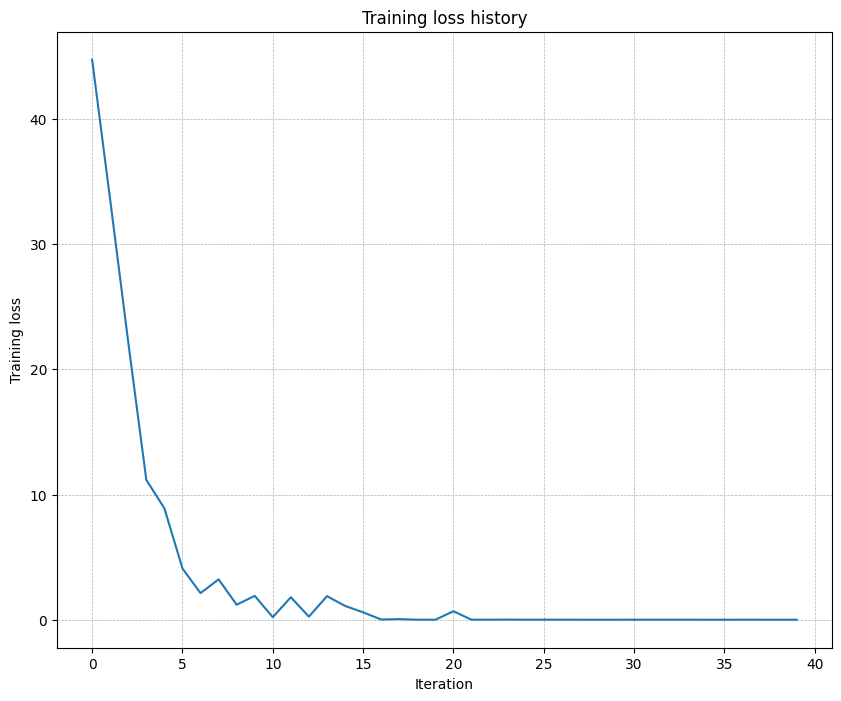

In [5]:
# TODO: Use a three-layer Net to overfit 50 training examples by
# tweaking just the learning rate and initialization scale.

num_train = 50
small_data = {
  "X_train": data["X_train"][:num_train],
  "y_train": data["y_train"][:num_train],
  "X_val": data["X_val"],
  "y_val": data["y_val"],
}

weight_scale = 1e-2   # Experiment with this!
learning_rate = 1e-4  # Experiment with this!

#weight_scale = 1
#overflow
weight_scale = 1e-1
weight_scale = 5e-2
learning_rate = 1e-3


model = FullyConnectedNet(
    [100, 100],
    weight_scale=weight_scale,
    dtype=np.float64
)
solver = Solver(
    model,
    small_data,
    print_every=10,
    num_epochs=20,
    batch_size=25,
    update_rule="sgd",
    optim_config={"learning_rate": learning_rate},
)
solver.train()

plt.plot(solver.loss_history)
plt.title("Training loss history")
plt.xlabel("Iteration")
plt.ylabel("Training loss")
plt.grid(linestyle='--', linewidth=0.5)
plt.show()

Now, try to use a five-layer network with 100 units on each layer to overfit on 50 training examples. Again, you will have to adjust the learning rate and weight initialization scale, but you should be able to achieve 100% training accuracy within 20 epochs.

(Iteration 1 / 40) loss: 5.557032
(Epoch 0 / 20) train acc: 0.200000; val_acc: 0.108000
(Epoch 1 / 20) train acc: 0.240000; val_acc: 0.085000
(Epoch 2 / 20) train acc: 0.260000; val_acc: 0.116000
(Epoch 3 / 20) train acc: 0.560000; val_acc: 0.125000
(Epoch 4 / 20) train acc: 0.700000; val_acc: 0.139000
(Epoch 5 / 20) train acc: 0.820000; val_acc: 0.133000
(Iteration 11 / 40) loss: 0.919214
(Epoch 6 / 20) train acc: 0.840000; val_acc: 0.134000
(Epoch 7 / 20) train acc: 0.880000; val_acc: 0.150000
(Epoch 8 / 20) train acc: 0.920000; val_acc: 0.146000
(Epoch 9 / 20) train acc: 0.960000; val_acc: 0.140000
(Epoch 10 / 20) train acc: 0.960000; val_acc: 0.147000
(Iteration 21 / 40) loss: 0.304914
(Epoch 11 / 20) train acc: 0.960000; val_acc: 0.149000
(Epoch 12 / 20) train acc: 0.960000; val_acc: 0.143000
(Epoch 13 / 20) train acc: 0.980000; val_acc: 0.155000
(Epoch 14 / 20) train acc: 1.000000; val_acc: 0.138000
(Epoch 15 / 20) train acc: 1.000000; val_acc: 0.141000
(Iteration 31 / 40) loss: 

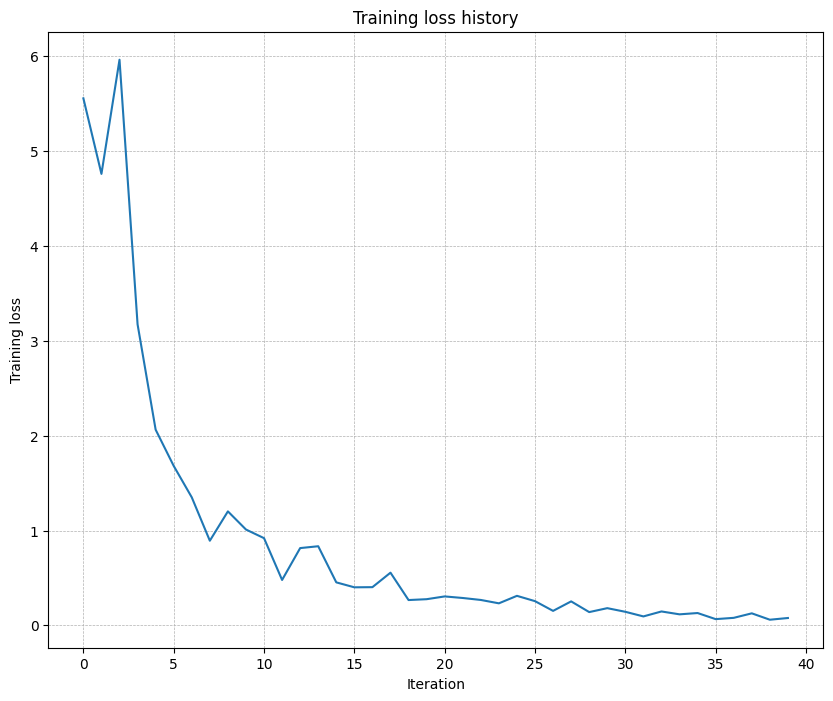

In [6]:
# TODO: Use a five-layer Net to overfit 50 training examples by
# tweaking just the learning rate and initialization scale.

num_train = 50
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

learning_rate = 2e-3  # Experiment with this!
weight_scale = 1e-5   # Experiment with this!

#weight_scale = 1e-1
#overflow
weight_scale = 5e-2
learning_rate = 1e-2

model = FullyConnectedNet(
    [100, 100, 100, 100],
    weight_scale=weight_scale,
    dtype=np.float64
)
solver = Solver(
    model,
    small_data,
    print_every=10,
    num_epochs=20,
    batch_size=25,
    update_rule='sgd',
    optim_config={'learning_rate': learning_rate},
)
solver.train()

plt.plot(solver.loss_history)
plt.title('Training loss history')
plt.xlabel('Iteration')
plt.ylabel('Training loss')
plt.grid(linestyle='--', linewidth=0.5)
plt.show()

## Inline Question 1:
Did you notice anything about the comparative difficulty of training the three-layer network vs. training the five-layer network? In particular, based on your experience, which network seemed more sensitive to the initialization scale? Why do you think that is the case?

## Answer:  
The five-layer network is more sensitive to the initialization scale than the three-layer network, and it's more likely to encounter vanishing and exploding gradient problem at the beginning of training the five-layer network.  
The weight parameters are initialized with the same initialization scale, and the values change exponentially through multiplications with weights of each layer. The loss can easily vanish to 0 if the initialization scale of weights is too small, or overflow if too large. This is more likely to happen as the number of layers increases, which makes the available range for the initialization scale smaller and the hyperparameter tuning harder for the five-layer network than the three-layer network.




# Update rules
So far we have used vanilla stochastic gradient descent (SGD) as our update rule. More sophisticated update rules can make it easier to train deep networks. We will implement a few of the most commonly used update rules and compare them to vanilla SGD.

## SGD+Momentum
Stochastic gradient descent with momentum is a widely used update rule that tends to make deep networks converge faster than vanilla stochastic gradient descent. See the Momentum Update section at http://cs231n.github.io/neural-networks-3/#sgd for more information.

Open the file `cs231n/optim.py` and read the documentation at the top of the file to make sure you understand the API. Implement the SGD+momentum update rule in the function `sgd_momentum` and run the following to check your implementation. You should see errors less than e-8.

In [7]:
from cs231n.optim import sgd_momentum

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
v = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)

config = {"learning_rate": 1e-3, "velocity": v}
next_w, _ = sgd_momentum(w, dw, config=config)

expected_next_w = np.asarray([
  [ 0.1406,      0.20738947,  0.27417895,  0.34096842,  0.40775789],
  [ 0.47454737,  0.54133684,  0.60812632,  0.67491579,  0.74170526],
  [ 0.80849474,  0.87528421,  0.94207368,  1.00886316,  1.07565263],
  [ 1.14244211,  1.20923158,  1.27602105,  1.34281053,  1.4096    ]])
expected_velocity = np.asarray([
  [ 0.5406,      0.55475789,  0.56891579, 0.58307368,  0.59723158],
  [ 0.61138947,  0.62554737,  0.63970526,  0.65386316,  0.66802105],
  [ 0.68217895,  0.69633684,  0.71049474,  0.72465263,  0.73881053],
  [ 0.75296842,  0.76712632,  0.78128421,  0.79544211,  0.8096    ]])

# Should see relative errors around e-8 or less
print("next_w error: ", rel_error(next_w, expected_next_w))
print("velocity error: ", rel_error(expected_velocity, config["velocity"]))

next_w error:  8.882347033505819e-09
velocity error:  4.269287743278663e-09


\begin{align}
v_t &= v_{t-1} - \alpha \left(\frac{\partial L}{\partial \theta}\right)_t \nonumber \\
\theta_t &= \theta_{t-1} + v_t \nonumber
\end{align}

Once you have done so, run the following to train a six-layer network with both SGD and SGD+momentum. You should see the SGD+momentum update rule converge faster.

Running with  sgd
(Iteration 1 / 200) loss: 2.559978
(Epoch 0 / 5) train acc: 0.104000; val_acc: 0.107000
(Iteration 11 / 200) loss: 2.356070
(Iteration 21 / 200) loss: 2.214091
(Iteration 31 / 200) loss: 2.205928
(Epoch 1 / 5) train acc: 0.225000; val_acc: 0.193000
(Iteration 41 / 200) loss: 2.132095
(Iteration 51 / 200) loss: 2.118950
(Iteration 61 / 200) loss: 2.116443
(Iteration 71 / 200) loss: 2.132549
(Epoch 2 / 5) train acc: 0.298000; val_acc: 0.260000
(Iteration 81 / 200) loss: 1.977227
(Iteration 91 / 200) loss: 2.007528
(Iteration 101 / 200) loss: 2.004762
(Iteration 111 / 200) loss: 1.885342
(Epoch 3 / 5) train acc: 0.343000; val_acc: 0.287000
(Iteration 121 / 200) loss: 1.891517
(Iteration 131 / 200) loss: 1.923677
(Iteration 141 / 200) loss: 1.957743
(Iteration 151 / 200) loss: 1.966736
(Epoch 4 / 5) train acc: 0.322000; val_acc: 0.305000
(Iteration 161 / 200) loss: 1.801483
(Iteration 171 / 200) loss: 1.973779
(Iteration 181 / 200) loss: 1.666572
(Iteration 191 / 200) los

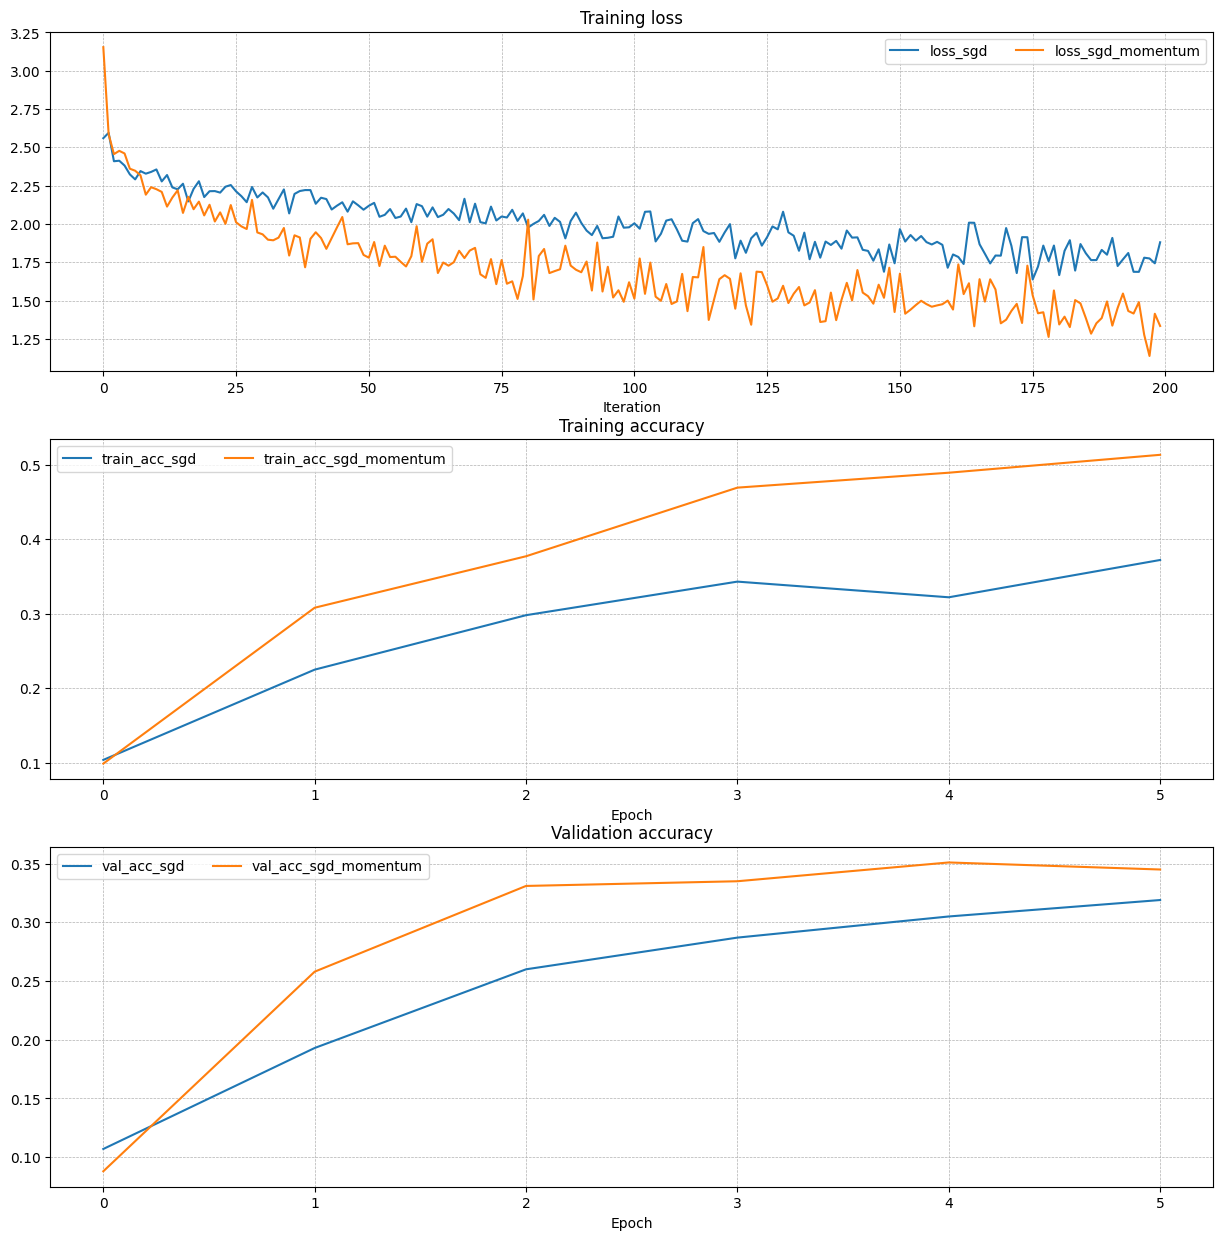

In [8]:
num_train = 4000
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

solvers = {}

for update_rule in ['sgd', 'sgd_momentum']:
    print('Running with ', update_rule)
    model = FullyConnectedNet(
        [100, 100, 100, 100, 100],
        weight_scale=5e-2
    )

    solver = Solver(
        model,
        small_data,
        num_epochs=5,
        batch_size=100,
        update_rule=update_rule,
        optim_config={'learning_rate': 5e-3},
        verbose=True,
    )
    solvers[update_rule] = solver
    solver.train()

fig, axes = plt.subplots(3, 1, figsize=(15, 15))

axes[0].set_title('Training loss')
axes[0].set_xlabel('Iteration')
axes[1].set_title('Training accuracy')
axes[1].set_xlabel('Epoch')
axes[2].set_title('Validation accuracy')
axes[2].set_xlabel('Epoch')

for update_rule, solver in solvers.items():
    axes[0].plot(solver.loss_history, label=f"loss_{update_rule}")
    axes[1].plot(solver.train_acc_history, label=f"train_acc_{update_rule}")
    axes[2].plot(solver.val_acc_history, label=f"val_acc_{update_rule}")

for ax in axes:
    ax.legend(loc="best", ncol=4)
    ax.grid(linestyle='--', linewidth=0.5)

plt.show()

## RMSProp and Adam
RMSProp [1] and Adam [2] are update rules that set per-parameter learning rates by using a running average of the second moments of gradients.

In the file `cs231n/optim.py`, implement the RMSProp update rule in the `rmsprop` function and implement the Adam update rule in the `adam` function, and check your implementations using the tests below.

**NOTE:** Please implement the _complete_ Adam update rule (with the bias correction mechanism), not the first simplified version mentioned in the course notes.

[1] Tijmen Tieleman and Geoffrey Hinton. "Lecture 6.5-rmsprop: Divide the gradient by a running average of its recent magnitude." COURSERA: Neural Networks for Machine Learning 4 (2012).

[2] Diederik Kingma and Jimmy Ba, "Adam: A Method for Stochastic Optimization", ICLR 2015.

In [9]:
# Test RMSProp implementation
from cs231n.optim import rmsprop

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
cache = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)

config = {'learning_rate': 1e-2, 'cache': cache}
next_w, _ = rmsprop(w, dw, config=config)

expected_next_w = np.asarray([
  [-0.39223849, -0.34037513, -0.28849239, -0.23659121, -0.18467247],
  [-0.132737,   -0.08078555, -0.02881884,  0.02316247,  0.07515774],
  [ 0.12716641,  0.17918792,  0.23122175,  0.28326742,  0.33532447],
  [ 0.38739248,  0.43947102,  0.49155973,  0.54365823,  0.59576619]])
expected_cache = np.asarray([
  [ 0.5976,      0.6126277,   0.6277108,   0.64284931,  0.65804321],
  [ 0.67329252,  0.68859723,  0.70395734,  0.71937285,  0.73484377],
  [ 0.75037008,  0.7659518,   0.78158892,  0.79728144,  0.81302936],
  [ 0.82883269,  0.84469141,  0.86060554,  0.87657507,  0.8926    ]])

# You should see relative errors around e-7 or less
print('next_w error: ', rel_error(expected_next_w, next_w))
print('cache error: ', rel_error(expected_cache, config['cache']))

next_w error:  9.502645229894295e-08
cache error:  2.6477955807156126e-09


\begin{align}
v_t &= \rho v_{t-1} + (1-\rho) \left(\frac{\partial L}{\partial \theta}\right)_t \odot \left(\frac{\partial L}{\partial \theta}\right)_t \nonumber \\
\theta_t &= \theta_{t-1} - \alpha \left(\frac{\partial L}{\partial \theta}\right)_t / (v_t+\epsilon) \nonumber
\end{align}

In [10]:
# Test Adam implementation
from cs231n.optim import adam

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
m = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)
v = np.linspace(0.7, 0.5, num=N*D).reshape(N, D)

config = {'learning_rate': 1e-2, 'm': m, 'v': v, 't': 5}
next_w, _ = adam(w, dw, config=config)

expected_next_w = np.asarray([
  [-0.40094747, -0.34836187, -0.29577703, -0.24319299, -0.19060977],
  [-0.1380274,  -0.08544591, -0.03286534,  0.01971428,  0.0722929],
  [ 0.1248705,   0.17744702,  0.23002243,  0.28259667,  0.33516969],
  [ 0.38774145,  0.44031188,  0.49288093,  0.54544852,  0.59801459]])
expected_v = np.asarray([
  [ 0.69966,     0.68908382,  0.67851319,  0.66794809,  0.65738853,],
  [ 0.64683452,  0.63628604,  0.6257431,   0.61520571,  0.60467385,],
  [ 0.59414753,  0.58362676,  0.57311152,  0.56260183,  0.55209767,],
  [ 0.54159906,  0.53110598,  0.52061845,  0.51013645,  0.49966,   ]])
expected_m = np.asarray([
  [ 0.48,        0.49947368,  0.51894737,  0.53842105,  0.55789474],
  [ 0.57736842,  0.59684211,  0.61631579,  0.63578947,  0.65526316],
  [ 0.67473684,  0.69421053,  0.71368421,  0.73315789,  0.75263158],
  [ 0.77210526,  0.79157895,  0.81105263,  0.83052632,  0.85      ]])

# You should see relative errors around e-7 or less
print('next_w error: ', rel_error(expected_next_w, next_w))
print('v error: ', rel_error(expected_v, config['v']))
print('m error: ', rel_error(expected_m, config['m']))

next_w error:  1.139887467333134e-07
v error:  4.208314038113071e-09
m error:  4.214963193114416e-09


\begin{align}
m_t &= \beta_1 m_{t-1} + (1-\beta_1) \left(\frac{\partial L}{\partial \theta}\right)_t \nonumber \\
v_t &= \beta_2 v_{t-1} + (1-\beta_2) \left(\frac{\partial L}{\partial \theta}\right)_t \odot \left(\frac{\partial L}{\partial \theta}\right)_t \nonumber \\
\hat{m_t} &= \frac{m_t}{1-\beta_1^t} \nonumber \\
\hat{v_t} &= \frac{v_t}{1-\beta_2^t} \nonumber \\
\theta_t &= \theta_{t-1} - \alpha \hat{m_t} / (\hat{v_t}+\epsilon) \nonumber
\end{align}

Once you have debugged your RMSProp and Adam implementations, run the following to train a pair of deep networks using these new update rules:

Running with  adam
(Iteration 1 / 200) loss: 3.476928
(Epoch 0 / 5) train acc: 0.126000; val_acc: 0.110000
(Iteration 11 / 200) loss: 2.015214
(Iteration 21 / 200) loss: 2.190157
(Iteration 31 / 200) loss: 1.785418
(Epoch 1 / 5) train acc: 0.387000; val_acc: 0.335000
(Iteration 41 / 200) loss: 1.743079
(Iteration 51 / 200) loss: 1.731332
(Iteration 61 / 200) loss: 1.992775
(Iteration 71 / 200) loss: 1.593985
(Epoch 2 / 5) train acc: 0.436000; val_acc: 0.360000
(Iteration 81 / 200) loss: 1.626604
(Iteration 91 / 200) loss: 1.494471
(Iteration 101 / 200) loss: 1.445403
(Iteration 111 / 200) loss: 1.398111
(Epoch 3 / 5) train acc: 0.501000; val_acc: 0.370000
(Iteration 121 / 200) loss: 1.217441
(Iteration 131 / 200) loss: 1.467958
(Iteration 141 / 200) loss: 1.432423
(Iteration 151 / 200) loss: 1.261458
(Epoch 4 / 5) train acc: 0.545000; val_acc: 0.394000
(Iteration 161 / 200) loss: 1.396795
(Iteration 171 / 200) loss: 1.269856
(Iteration 181 / 200) loss: 1.184783
(Iteration 191 / 200) lo

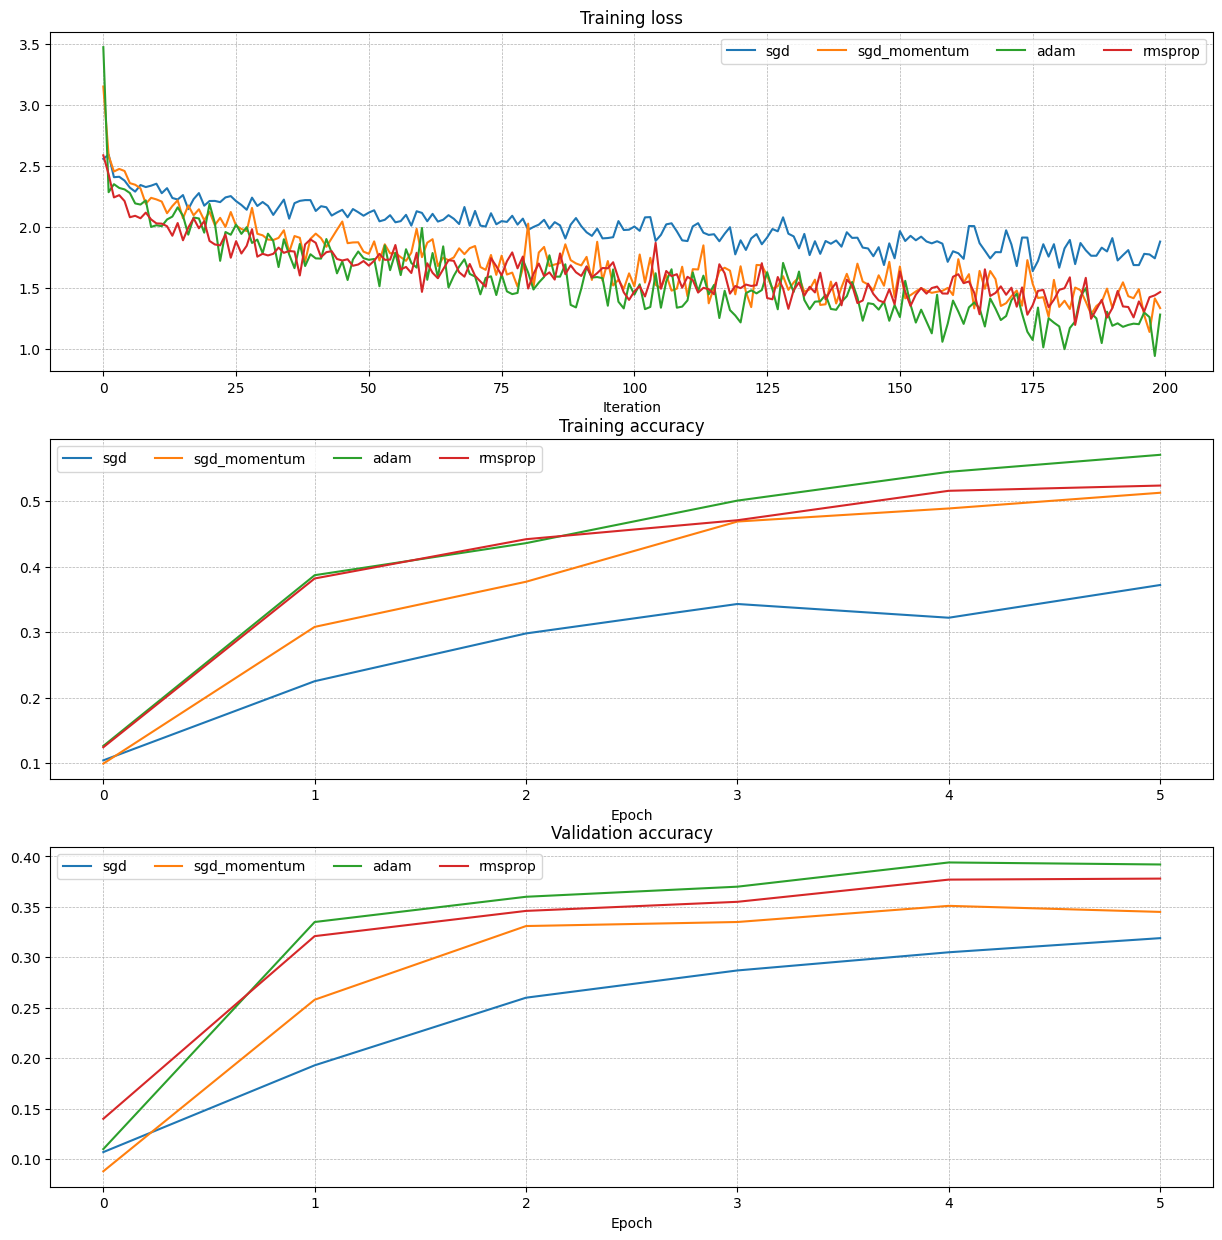

In [11]:
learning_rates = {'rmsprop': 1e-4, 'adam': 1e-3}
for update_rule in ['adam', 'rmsprop']:
    print('Running with ', update_rule)
    model = FullyConnectedNet(
        [100, 100, 100, 100, 100],
        weight_scale=5e-2
    )
    solver = Solver(
        model,
        small_data,
        num_epochs=5,
        batch_size=100,
        update_rule=update_rule,
        optim_config={'learning_rate': learning_rates[update_rule]},
        verbose=True
    )
    solvers[update_rule] = solver
    solver.train()
    print()

fig, axes = plt.subplots(3, 1, figsize=(15, 15))

axes[0].set_title('Training loss')
axes[0].set_xlabel('Iteration')
axes[1].set_title('Training accuracy')
axes[1].set_xlabel('Epoch')
axes[2].set_title('Validation accuracy')
axes[2].set_xlabel('Epoch')

for update_rule, solver in solvers.items():
    axes[0].plot(solver.loss_history, label=f"{update_rule}")
    axes[1].plot(solver.train_acc_history, label=f"{update_rule}")
    axes[2].plot(solver.val_acc_history, label=f"{update_rule}")

for ax in axes:
    ax.legend(loc='best', ncol=4)
    ax.grid(linestyle='--', linewidth=0.5)

plt.show()

## Inline Question 2:

AdaGrad, like Adam, is a per-parameter optimization method that uses the following update rule:

```
cache += dw**2
w += - learning_rate * dw / (np.sqrt(cache) + eps)
```

John notices that when he was training a network with AdaGrad that the updates became very small, and that his network was learning slowly. Using your knowledge of the AdaGrad update rule, why do you think the updates would become very small? Would Adam have the same issue?


## Answer:  
As the number of iterations increases the second momentum $v$ accumulates so that updates $\alpha \frac{\nabla W}{\sqrt{v + \epsilon}}$ become small.  
Adam adapts the second momentum (and the first momentum as well) by dividing it by $(1 - \beta_2^t)$ (and $(1 - \beta_1^t)$ respectively) to reduce the effect of accumulation, and thus it doesn't have the issue.




# Train a Good Model!
Train the best fully connected model that you can on CIFAR-10, storing your best model in the `best_model` variable. We require you to get at least 50% accuracy on the validation set using a fully connected network.

If you are careful it should be possible to get accuracies above 55%, but we don't require it for this part and won't assign extra credit for doing so. Later in the next assignment, we will ask you to train the best convolutional network that you can on CIFAR-10, and we would prefer that you spend your effort working on convolutional networks rather than fully connected networks.

**Note:** In the next assignment, you will learn techniques like BatchNormalization and Dropout which can help you train powerful models.

lr=5.693362e-04; reg=1.656331e-05; lr_decay=0.602756	loss: 1.225037; train acc: 0.567000; val_acc: 0.514000
lr=5.588732e-04; reg=9.673133e-06; lr_decay=0.671780	loss: 1.013061; train acc: 0.611000; val_acc: 0.502000
lr=6.903443e-04; reg=5.226610e-05; lr_decay=0.829383	loss: 1.036552; train acc: 0.607000; val_acc: 0.529000
lr=5.541641e-04; reg=2.664189e-06; lr_decay=0.831297	loss: 1.140600; train acc: 0.647000; val_acc: 0.539000
lr=8.834094e-04; reg=1.657433e-05; lr_decay=0.694605	loss: 1.068833; train acc: 0.640000; val_acc: 0.555000
lr=3.269993e-04; reg=1.312282e-06; lr_decay=0.633594	loss: 1.290784; train acc: 0.514000; val_acc: 0.503000
lr=6.823138e-04; reg=1.915326e-05; lr_decay=0.745200	loss: 1.139124; train acc: 0.597000; val_acc: 0.528000
lr=8.556769e-04; reg=1.594786e-05; lr_decay=0.717310	loss: 1.036791; train acc: 0.587000; val_acc: 0.521000
lr=9.871102e-04; reg=6.115786e-06; lr_decay=0.854553	loss: 1.054658; train acc: 0.590000; val_acc: 0.515000
lr=5.078197e-04; reg=2.50827

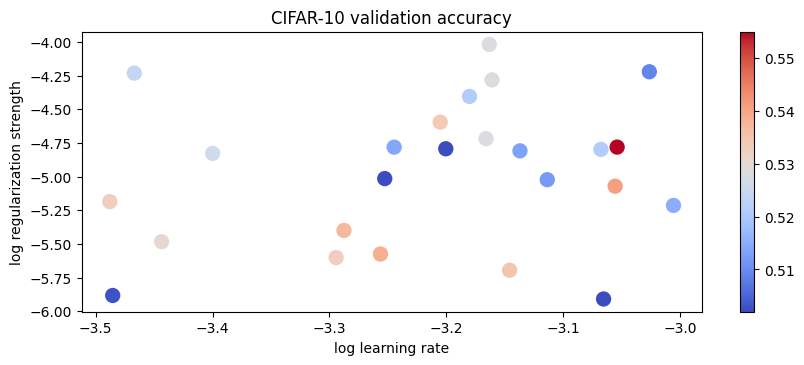

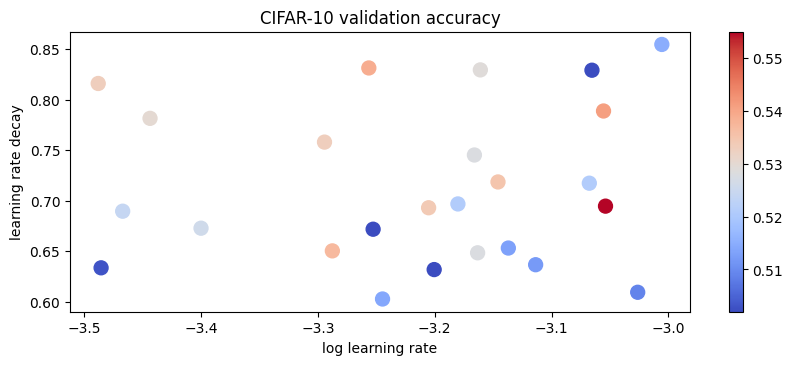

In [22]:
best_model = None

################################################################################
# TODO: Train the best FullyConnectedNet that you can on CIFAR-10. You might   #
# find batch/layer normalization and dropout useful. Store your best model in  #
# the best_model variable.                                                     #
################################################################################
# *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
input_dim = 32 * 32 * 3
hidden_dims = [100, 50]
num_classes = 10

update_rule = 'sgd'
config_range = {
    'lr': (-2.5, -1.5),
    'reg': (-3, -7),
    'lr_decay': (0.65, 0.95)
}
'''lr=1.999485e-02; reg=1.361876e-07; lr_decay=0.828295	loss: 1.213414; train acc: 0.608000; val_acc: 0.539000
lr=1.450859e-02; reg=9.433361e-07; lr_decay=0.906617	loss: 1.229915; train acc: 0.583000; val_acc: 0.512000
lr=4.316737e-03; reg=1.475048e-05; lr_decay=0.706959	loss: 2.199101; train acc: 0.195000; val_acc: 0.187000
lr=1.481308e-02; reg=4.771488e-07; lr_decay=0.710697	loss: 1.066440; train acc: 0.555000; val_acc: 0.509000
lr=1.775445e-02; reg=8.703646e-06; lr_decay=0.793888	loss: 1.013274; train acc: 0.568000; val_acc: 0.518000
lr=2.546332e-02; reg=2.310752e-04; lr_decay=0.683592	loss: 1.134603; train acc: 0.567000; val_acc: 0.538000
lr=3.257536e-03; reg=6.568666e-05; lr_decay=0.652695	loss: 2.302252; train acc: 0.125000; val_acc: 0.090000
lr=4.307764e-03; reg=3.028587e-04; lr_decay=0.741098	loss: 2.125499; train acc: 0.204000; val_acc: 0.211000
lr=3.149813e-02; reg=4.391748e-06; lr_decay=0.750704	loss: 1.094118; train acc: 0.592000; val_acc: 0.533000
lr=1.978402e-02; reg=1.243879e-07; lr_decay=0.743090	loss: 1.084993; train acc: 0.553000; val_acc: 0.530000
lr=2.984323e-02; reg=1.023013e-07; lr_decay=0.660127	loss: 1.225442; train acc: 0.604000; val_acc: 0.528000
lr=3.303835e-03; reg=8.768768e-04; lr_decay=0.901939	loss: 1.814944; train acc: 0.328000; val_acc: 0.340000
lr=7.117426e-03; reg=4.663856e-05; lr_decay=0.764144	loss: 1.560855; train acc: 0.408000; val_acc: 0.438000
lr=9.916552e-03; reg=4.635293e-05; lr_decay=0.838506	loss: 1.372874; train acc: 0.570000; val_acc: 0.528000
lr=2.518020e-02; reg=4.475760e-07; lr_decay=0.663297	loss: 1.261175; train acc: 0.584000; val_acc: 0.517000
lr=3.276170e-03; reg=3.775973e-05; lr_decay=0.926182	loss: 1.766051; train acc: 0.342000; val_acc: 0.347000
lr=4.557787e-03; reg=8.632735e-04; lr_decay=0.738000	loss: 2.028640; train acc: 0.212000; val_acc: 0.205000
lr=7.041381e-03; reg=5.687057e-05; lr_decay=0.778063	loss: 1.606040; train acc: 0.445000; val_acc: 0.449000
lr=1.613061e-02; reg=1.100912e-06; lr_decay=0.738698	loss: 1.116811; train acc: 0.576000; val_acc: 0.519000
lr=5.923132e-03; reg=3.498024e-07; lr_decay=0.917701	loss: 1.437908; train acc: 0.526000; val_acc: 0.474000
lr=4.920704e-03; reg=1.278299e-05; lr_decay=0.881729	loss: 1.601444; train acc: 0.437000; val_acc: 0.461000
lr=4.031612e-03; reg=8.275629e-05; lr_decay=0.843073	loss: 1.893760; train acc: 0.285000; val_acc: 0.299000
lr=2.275272e-02; reg=3.524146e-07; lr_decay=0.917667	loss: 1.169827; train acc: 0.589000; val_acc: 0.505000
lr=2.595703e-02; reg=2.002749e-06; lr_decay=0.674789	loss: 1.200185; train acc: 0.590000; val_acc: 0.527000
lr=8.640103e-03; reg=1.598805e-07; lr_decay=0.816417	loss: 1.355828; train acc: 0.519000; val_acc: 0.499000'''

config_range = {
    'lr': (-2, -1.5),
    'reg': (-4, -6),
    'lr_decay': (0.6, 0.9)
}
'''lr=1.485067e-02; reg=2.758749e-05; lr_decay=0.658664	loss: 1.294937; train acc: 0.514000; val_acc: 0.505000
lr=2.433042e-02; reg=1.572823e-06; lr_decay=0.843753	loss: 1.196584; train acc: 0.602000; val_acc: 0.513000
lr=2.842862e-02; reg=7.418370e-06; lr_decay=0.759732	loss: 1.089353; train acc: 0.581000; val_acc: 0.528000
lr=2.149129e-02; reg=8.785411e-05; lr_decay=0.873377	loss: 1.253128; train acc: 0.595000; val_acc: 0.520000
lr=1.628024e-02; reg=8.552002e-06; lr_decay=0.695571	loss: 1.283818; train acc: 0.552000; val_acc: 0.514000
lr=1.143313e-02; reg=1.551888e-06; lr_decay=0.885899	loss: 1.206677; train acc: 0.591000; val_acc: 0.530000
lr=1.739226e-02; reg=5.701685e-06; lr_decay=0.658918	loss: 1.360564; train acc: 0.563000; val_acc: 0.512000
lr=1.019837e-02; reg=1.160704e-05; lr_decay=0.721451	loss: 1.362782; train acc: 0.473000; val_acc: 0.482000
lr=1.831181e-02; reg=1.512629e-06; lr_decay=0.847296	loss: 1.202857; train acc: 0.608000; val_acc: 0.543000
lr=2.171003e-02; reg=1.010208e-06; lr_decay=0.651287	loss: 1.228734; train acc: 0.574000; val_acc: 0.521000
lr=2.592865e-02; reg=2.930205e-05; lr_decay=0.706440	loss: 1.148538; train acc: 0.612000; val_acc: 0.532000
lr=2.966914e-02; reg=4.997211e-05; lr_decay=0.713410	loss: 1.157089; train acc: 0.588000; val_acc: 0.527000
lr=2.321288e-02; reg=8.129792e-05; lr_decay=0.836336	loss: 1.121923; train acc: 0.613000; val_acc: 0.530000
lr=3.056066e-02; reg=6.915230e-06; lr_decay=0.783566	loss: 1.161042; train acc: 0.591000; val_acc: 0.531000
lr=1.377568e-02; reg=2.319426e-05; lr_decay=0.672700	loss: 1.351538; train acc: 0.506000; val_acc: 0.503000
lr=3.072568e-02; reg=2.768383e-06; lr_decay=0.777006	loss: 1.164987; train acc: 0.592000; val_acc: 0.521000
lr=1.963146e-02; reg=6.437682e-05; lr_decay=0.649749	loss: 1.286848; train acc: 0.562000; val_acc: 0.522000
lr=2.184696e-02; reg=1.095613e-05; lr_decay=0.635772	loss: 1.113659; train acc: 0.554000; val_acc: 0.507000
lr=2.058035e-02; reg=1.704157e-05; lr_decay=0.642510	loss: 1.196685; train acc: 0.570000; val_acc: 0.519000
lr=1.603643e-02; reg=1.079431e-05; lr_decay=0.884719	loss: 1.106784; train acc: 0.590000; val_acc: 0.524000
lr=1.507061e-02; reg=3.155158e-05; lr_decay=0.850986	loss: 1.145565; train acc: 0.595000; val_acc: 0.524000
lr=2.695145e-02; reg=3.232844e-06; lr_decay=0.678761	loss: 1.070084; train acc: 0.580000; val_acc: 0.531000
lr=2.865031e-02; reg=1.806390e-06; lr_decay=0.681138	loss: 1.123981; train acc: 0.571000; val_acc: 0.517000
lr=1.785011e-02; reg=1.317783e-05; lr_decay=0.619347	loss: 1.322394; train acc: 0.519000; val_acc: 0.498000
lr=1.043902e-02; reg=1.665246e-05; lr_decay=0.699227	loss: 1.565676; train acc: 0.521000; val_acc: 0.484000'''

update_rule = 'adam'
config_range = {
    'lr': (-3.5, -3),
    'reg': (-4, -6),
    'lr_decay': (0.6, 0.9)
}

best_val = -1
results = {}
for i in range(25):
    lr = 10 ** np.random.uniform(*config_range['lr'])
    reg = 10 ** np.random.uniform(*config_range['reg'])
    lr_decay = np.random.uniform(*config_range['lr_decay'])
    model = FullyConnectedNet(hidden_dims, input_dim, num_classes, weight_scale=5e-4, reg=reg)
    solver = Solver(model, data,
                    update_rule=update_rule,
                    optim_config={
                        'learning_rate': lr,
                    },
                    lr_decay=lr_decay,
                    num_epochs=10, batch_size=200,
                    verbose=False, print_every=250)
    solver.train()
    print("lr=%4e; reg=%4e; lr_decay=%4f"%(lr, reg, lr_decay), end="\t")
    print("loss: %4f; train acc: %4f; val_acc: %4f"%(solver.loss_history[-1], solver.train_acc_history[-1], solver.val_acc_history[-1]))
    results[(lr, reg, lr_decay)] = (solver.train_acc_history[-1], solver.val_acc_history[-1])
    if solver.val_acc_history[-1] > best_val:
        best_val = solver.val_acc_history[-1]
        best_model = model

import math
x_scatter = [math.log10(x[0]) for x in results]
y_scatter = [math.log10(x[1]) for x in results]
z_scatter = [x[2] for x in results]
marker_size = 100
colors = [results[x][1] for x in results]
plt.subplot(2, 1, 1)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 validation accuracy')
plt.show()
plt.subplot(2, 1, 2)
plt.scatter(x_scatter, z_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('learning rate decay')
plt.title('CIFAR-10 validation accuracy')
plt.show()

# *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
################################################################################
#                              END OF YOUR CODE                                #
################################################################################

# Test Your Model!
Run your best model on the validation and test sets. You should achieve at least 50% accuracy on the validation set and the test set.

In [23]:
y_test_pred = np.argmax(best_model.loss(data['X_test']), axis=1)
y_val_pred = np.argmax(best_model.loss(data['X_val']), axis=1)
print('Validation set accuracy: ', (y_val_pred == data['y_val']).mean())
print('Test set accuracy: ', (y_test_pred == data['y_test']).mean())

Validation set accuracy:  0.555
Test set accuracy:  0.533
